In [1]:
import sys, os, json
import pandas as pd
import seaborn as sns

from pathlib import Path

sys.path.insert(1,os.path.abspath('..'))
from tools.battle import *

In [26]:
REPLAYS_1 = Path("../data/replays/gen9-randombattle")
REPLAYS_2 = Path("../data/replays/gen9-randombattle_2")
REPLAYS_3 = Path("../data/replays/gen9-randombattle_3")

with open("../data/POKEDEX.json", "r") as file:
    POKEDEX = json.load(file)

# helpful to not have to use the full filename
def pull_by_num(num, ns=''):
    return Battle(f'./../data/replays/gen9-randombattle{ns}/gen9randombattle-{num}.json')

In [ ]:
# bat = pull_by_num(2631368445)
# bat.teams_full[0]

## Getting list of all seen Pokemon; making dataframe

In [31]:
dex = {} # "Pokedex" made from teams data

for item in REPLAYS_1.iterdir():
    if item.is_file() and item.name.endswith(".json"):
        try: 
            bat = Battle(item)

            # add entries indexed by `speciesId`
            for team in bat.teams_full : 
                for key in team.keys() : 
                    mon = team[key]
                    dex[mon['speciesId']] = mon
        except: 
            print(f"error with {file.stem}")
            error_ids.append(file.stem)
            continue

len(dex) # 508; if I run the above with REPLAYS_2, no more were added, so it seems REPLAYS_1 is enough. 

508

In [36]:
dex_list = sorted(list(dex.keys()))
adv_mat = [
    [FullPokemon.advantage(FullPokemon(dex[M1]), FullPokemon(dex[M2])) for M2 in dex_list] for M1 in dex_list
]
df_adv = pd.DataFrame(adv_mat, index=dex_list, columns=dex_list)

In [38]:
df_adv

,abomasnow,alcremie,alomomola,altaria,ambipom,amoonguss,ampharos,annihilape,appletun,araquanid,...,zamazenta,zamazentacrowned,zangoose,zapdos,zapdosgalar,zarude,zebstrika,zekrom,zoroark,zoroarkhisui
abomasnow,0.000000,-0.501557,0.769821,0.529597,-0.650653,0.670717,0.227137,-0.959931,1.505688,-0.359834,...,-0.857936,-0.940352,-0.371414,-0.636105,-0.738382,0.227048,0.410175,0.505745,-0.458260,-0.506951
alcremie,0.501557,0.000000,0.544680,0.691511,-0.555138,-0.847244,0.118870,0.962656,0.927150,0.471374,...,1.394414,-0.722838,0.260600,0.520331,1.047823,0.652434,-0.508081,1.093650,1.055582,0.567799
alomomola,-0.769821,-0.544680,0.000000,-0.468082,0.119786,-0.670739,-0.901769,0.448536,-1.362140,0.131199,...,0.470034,0.446128,0.401596,-0.995790,0.377579,-0.974137,-0.856866,-1.028786,-0.520881,-0.541824
altaria,-0.529597,-0.691511,0.468082,0.000000,-0.619809,0.901926,-0.697880,0.964935,-0.407369,1.133055,...,0.940163,0.176772,-0.270516,-0.159626,0.638390,0.258465,-0.559517,0.502573,-0.307142,-0.328015
ambipom,0.650653,0.555138,-0.119786,0.619809,0.000000,0.646082,-0.653774,-1.190467,0.121488,0.764142,...,0.324319,-0.821513,0.833793,0.660701,-1.154467,-0.181560,-0.562783,0.590236,0.892442,-0.795812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zarude,-0.227048,-0.652434,0.974137,-0.258465,0.181560,-0.156517,0.532975,-0.181588,-0.183198,-0.845430,...,-0.562313,-0.977544,0.780640,-0.389217,-0.971793,0.000000,0.615384,0.628841,0.816920,0.910897
zebstrika,-0.410175,0.508081,0.856866,0.559517,0.562783,-0.329776,-0.493677,0.631718,-1.092593,1.006015,...,0.765179,0.720109,0.764238,0.814556,0.598966,-0.615384,0.000000,-0.772569,0.814454,0.908493
zekrom,-0.505745,-1.093650,1.028786,-0.502573,-0.590236,0.467206,0.500033,0.196655,0.126300,1.214204,...,0.231235,-0.027063,-0.213193,0.533199,0.805780,-0.628841,0.772569,0.000000,-0.578467,-0.632803
zoroark,0.458260,-1.055582,0.520881,0.307142,-0.892442,0.490930,-1.019247,-0.897117,-0.467293,-0.694476,...,-1.449899,-1.097487,0.714605,0.515085,-1.022742,-0.816920,-0.814454,0.578467,0.000000,0.828373


## Examining

<Axes: >

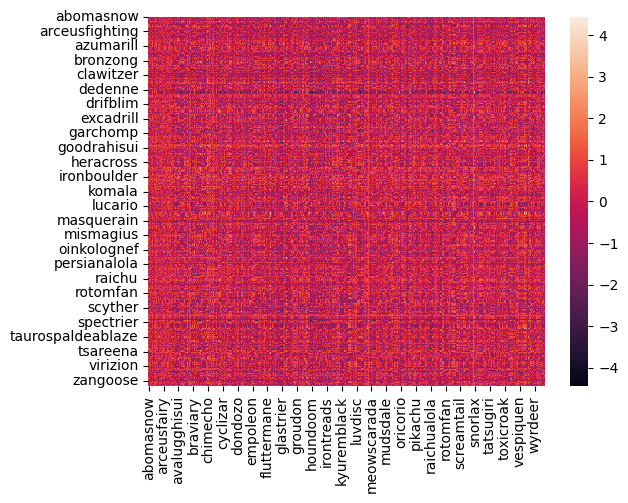

In [39]:
sns.heatmap(df_adv)

In [44]:
# Averaging
ser = df_adv.mean(axis=1).sort_values(ascending=False)
print(ser.head(10))
print("...")
print(ser.tail(10))

slaking         0.879567
golemalola      0.678233
glastrier       0.646335
palkia          0.630073
crabominable    0.583335
oranguru        0.550847
mamoswine       0.550705
hoopa           0.535487
walkingwake     0.510968
terrakion       0.494287
dtype: float64
...
cloyster       -0.497449
bellossom      -0.502082
deoxys         -0.518519
venomoth       -0.527515
cinccino       -0.564467
serperior      -0.583505
vivillon       -0.599313
maushold       -0.862462
smeargle       -1.052842
deoxysattack   -1.064229
dtype: float64
